In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from wordcloud import WordCloud
import nltk
import re

# import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

# Load the dataset (Make sure 'goldstandard_eng.csv' is uploaded to your Colab session)
df = pd.read_csv('goldstandard_eng.csv')

# Data Cleaning and Feature Engineering

# A. Handle Missing Values
text_cols = ['s:name', 's:description', 's:category', 's:brand']
for col in text_cols:
    # Fill text NaNs with empty string
    df[col] = df[col].fillna('')

# Drop rows where the target is missing
df.dropna(subset=['GS1_Level1_Category'], inplace=True)

# B. Feature Engineering: Text Length (Numerical Feature)
df['name_length'] = df['s:name'].apply(len)
df['description_length'] = df['s:description'].apply(len)


host_freq = df['HOST'].value_counts(normalize=True)
df['HOST_freq'] = df['HOST'].map(host_freq)




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


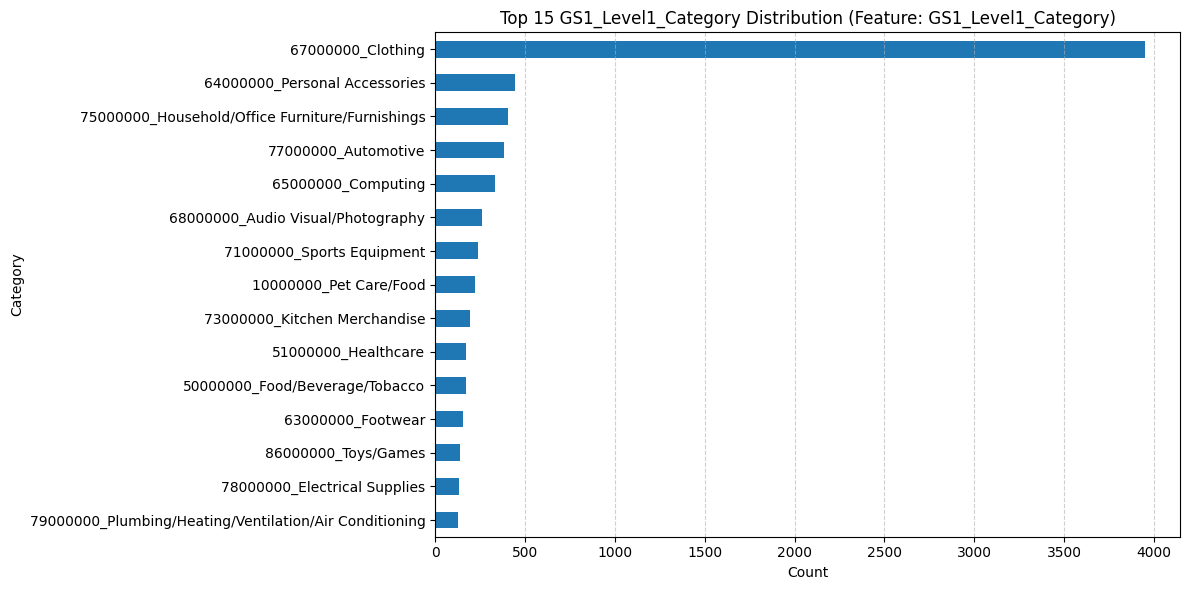

In [2]:
# --- 2. Exploratory Data Analysis (EDA) ---

# A. Target Variable Distribution (Level 1)
plt.figure(figsize=(12, 6))
df['GS1_Level1_Category'].value_counts().nlargest(15).sort_values(ascending=True).plot(kind='barh')
plt.title('Top 15 GS1_Level1_Category Distribution (Feature: GS1_Level1_Category)')
plt.xlabel('Count')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

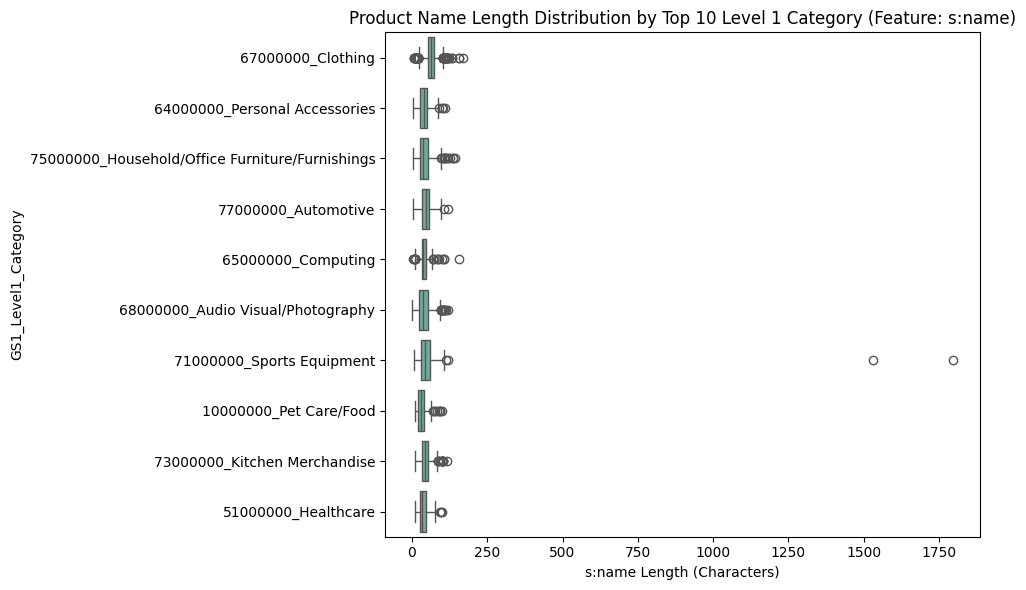

In [3]:
# B. Numerical Feature Distribution (Text Length vs. Target)
plt.figure(figsize=(10, 6))
top_10_categories = df['GS1_Level1_Category'].value_counts().nlargest(10).index
sns.boxplot(
    y='GS1_Level1_Category',
    x='name_length',
    data=df[df['GS1_Level1_Category'].isin(top_10_categories)],
    order=top_10_categories,
    orient='h',
    color='#69b3a2'
)
plt.title('Product Name Length Distribution by Top 10 Level 1 Category (Feature: s:name)')
plt.xlabel('s:name Length (Characters)')
plt.ylabel('GS1_Level1_Category')
plt.tight_layout()
plt.show()

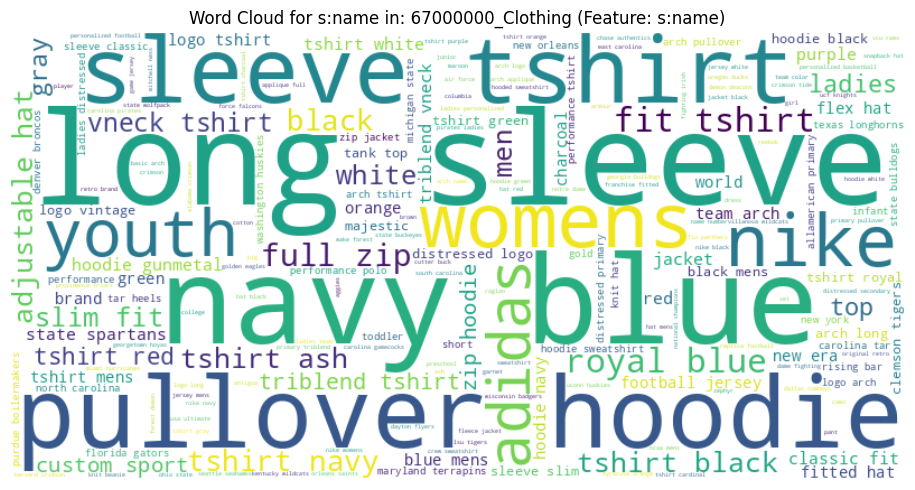

In [4]:
# C. Text Visualization: Word Cloud for the most frequent category
top_category_name = df['GS1_Level1_Category'].value_counts().index[0]
text = " ".join(review for review in df[df['GS1_Level1_Category'] == top_category_name]['s:name'])

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

text_cleaned = clean_text(text)

wordcloud = WordCloud(
    stopwords=STOPWORDS,
    background_color="white",
    width=800,
    height=400
).generate(text_cleaned)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title(f'Word Cloud for s:name in: {top_category_name} (Feature: s:name)')
plt.tight_layout()
plt.show()

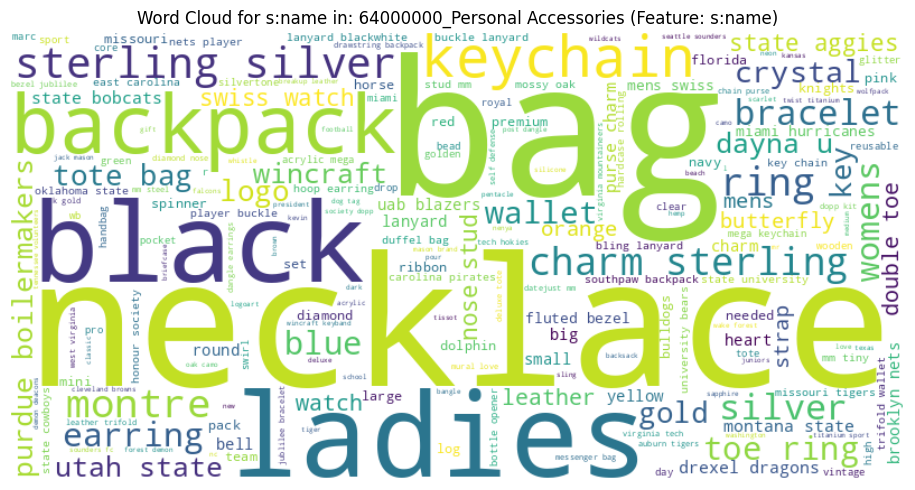

In [5]:
# C. Text Visualization: Word Cloud for the most frequent category
top_category_name = df['GS1_Level1_Category'].value_counts().index[1]
text = " ".join(review for review in df[df['GS1_Level1_Category'] == top_category_name]['s:name'])

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

text_cleaned = clean_text(text)

wordcloud = WordCloud(
    stopwords=STOPWORDS,
    background_color="white",
    width=800,
    height=400
).generate(text_cleaned)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title(f'Word Cloud for s:name in: {top_category_name} (Feature: s:name)')
plt.tight_layout()
plt.show()

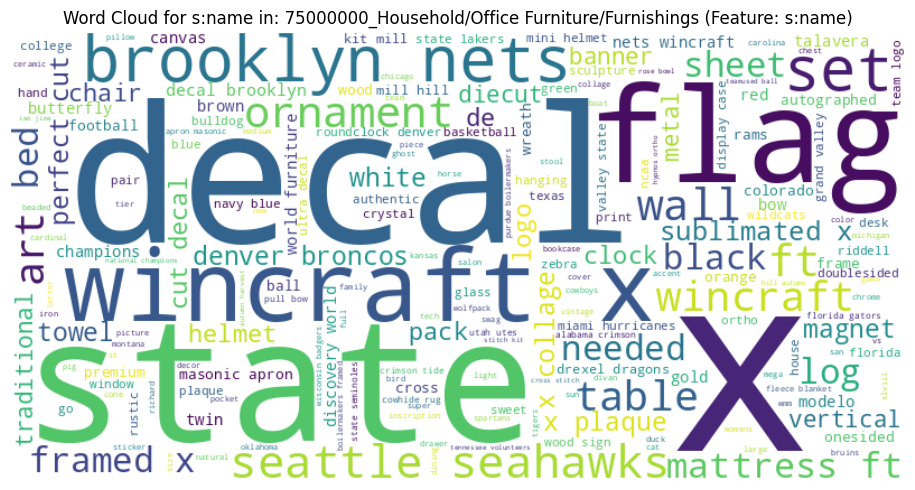

In [6]:
# C. Text Visualization: Word Cloud for the most frequent category
top_category_name = df['GS1_Level1_Category'].value_counts().index[2]
text = " ".join(review for review in df[df['GS1_Level1_Category'] == top_category_name]['s:name'])

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

text_cleaned = clean_text(text)

wordcloud = WordCloud(
    stopwords=STOPWORDS,
    background_color="white",
    width=800,
    height=400
).generate(text_cleaned)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title(f'Word Cloud for s:name in: {top_category_name} (Feature: s:name)')
plt.tight_layout()
plt.show()

In [7]:
# --- 3. Feature Importance Tests ---


# ANOVA for Numerical Feature (Length) vs. Target
anova_groups = []
top_5_categories = df['GS1_Level1_Category'].value_counts().nlargest(5).index
for category in top_5_categories:
    anova_groups.append(df[df['GS1_Level1_Category'] == category]['name_length'])

f_stat, p_anova = f_oneway(*anova_groups)

print("\n--- ANOVA Test: s:name Length vs. Top 5 GS1_Level1_Category ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-value: {p_anova:.4e}")
print("Conclusion: A P-value < 0.05 strongly suggests that the mean name length is statistically different across categories (i.e., length is important).")


--- ANOVA Test: s:name Length vs. Top 5 GS1_Level1_Category ---
F-Statistic: 346.73
P-value: 1.3795e-266
Conclusion: A P-value < 0.05 strongly suggests that the mean name length is statistically different across categories (i.e., length is important).


In [8]:
# Chi-Squared for Categorical Feature (HOST) vs. Target
top_hosts = df['HOST'].value_counts().nlargest(20).index
df_filtered = df[df['HOST'].isin(top_hosts)]
contingency_table_host = pd.crosstab(df_filtered['HOST'], df_filtered['GS1_Level1_Category'])
chi2, p, dof, expected = chi2_contingency(contingency_table_host)

print("\n--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---")
print(f"Chi-Squared Statistic: {chi2:.2f}")
print(f"P-value: {p:.4e}")
if p < 0.05:
    print("Conclusion: A P-value < 0.05 strongly suggests a statistical dependence (i.e., HOST is important).")
else:
    print("Conclusion: A P-value >= 0.05 suggests no statistical dependence (i.e., HOST is not important).")

#Chi-Squared for Categorical Feature (URL) vs. Target
top_url = df['URL'].value_counts().nlargest(20).index
df_filtered = df[df['URL'].isin(top_url)]
contingency_table_url = pd.crosstab(df_filtered['URL'], df_filtered['GS1_Level1_Category'])
chi2, p, dof, expected = chi2_contingency(contingency_table_url)

print("\n--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---")
print(f"Chi-Squared Statistic: {chi2:.2f}")
print(f"P-value: {p:.4e}")
if p < 0.05:
    print("Conclusion: A P-value < 0.05 strongly suggests a statistical dependence (i.e., URL is important).")
else:
    print("Conclusion: A P-value >= 0.05 suggests no statistical dependence (i.e., URL is not important).")


#Chi-Squared for Categorical Feature (Brand) vs. Target
top_brand = df['s:brand'].value_counts().nlargest(20).index
df_filtered = df[df['s:brand'].isin(top_brand)]
contingency_table_brand = pd.crosstab(df_filtered['s:brand'], df_filtered['GS1_Level1_Category'])
chi2, p, dof, expected = chi2_contingency(contingency_table_brand)

print("\n--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---")
print(f"Chi-Squared Statistic: {chi2:.2f}")
print(f"P-value: {p:.4e}")
if p < 0.05:
    print("Conclusion: A P-value < 0.05 strongly suggests a statistical dependence (i.e., brand is important).")
else:
    print("Conclusion: A P-value >= 0.05 suggests no statistical dependence (i.e., brand is not important).")


#Chi-Squared for Categorical Feature (breadcrumb) vs. Target
top_breadcrumb = df['s:breadcrumb'].value_counts().nlargest(20).index
df_filtered = df[df['s:breadcrumb'].isin(top_breadcrumb)]
contingency_table_breadcrumb = pd.crosstab(df_filtered['s:breadcrumb'], df_filtered['GS1_Level1_Category'])
chi2, p, dof, expected = chi2_contingency(contingency_table_breadcrumb)

print("\n--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---")
print(f"Chi-Squared Statistic: {chi2:.2f}")
print(f"P-value: {p:.4e}")
if p < 0.05:
    print("Conclusion: A P-value < 0.05 strongly suggests a statistical dependence (i.e., breadcrumb is important).")
else:
    print("Conclusion: A P-value >= 0.05 suggests no statistical dependence (i.e., breadcrumb is not important).")


#Chi-Squared for Categorical Feature (GeneratedID) vs. Target
top_GeneratedID = df['GeneratedID'].value_counts().nlargest(20).index
df_filtered = df[df['GeneratedID'].isin(top_GeneratedID)]
contingency_table_GeneratedID = pd.crosstab(df_filtered['GeneratedID'], df_filtered['GS1_Level1_Category'])
chi2, p, dof, expected = chi2_contingency(contingency_table_GeneratedID)

print("\n--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---")
print(f"Chi-Squared Statistic: {chi2:.2f}")
print(f"P-value: {p:.4e}")
if p < 0.05:
    print("Conclusion: A P-value < 0.05 strongly suggests a statistical dependence (i.e., GeneratedID is important).")
else:
    print("Conclusion: A P-value >= 0.05 suggests no statistical dependence (i.e., GeneratedID is not important).")


--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---
Chi-Squared Statistic: 3001.33
P-value: 0.0000e+00
Conclusion: A P-value < 0.05 strongly suggests a statistical dependence (i.e., HOST is important).

--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---
Chi-Squared Statistic: 476.06
P-value: 3.1174e-59
Conclusion: A P-value < 0.05 strongly suggests a statistical dependence (i.e., URL is important).

--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---
Chi-Squared Statistic: 7631.57
P-value: 0.0000e+00
Conclusion: A P-value < 0.05 strongly suggests a statistical dependence (i.e., brand is important).

--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---
Chi-Squared Statistic: 2391.92
P-value: 4.5423e-288
Conclusion: A P-value < 0.05 strongly suggests a statistical dependence (i.e., breadcrumb is important).

--- Chi-Squared Test: HOST vs. GS1_Level1_Category (Top 20 Hosts) ---
Chi-Squared Statistic: 21.00
P-value: 3

In [9]:
pd.set_option("display.max_rows", None)
print(df["GS1_Level1_Category"].value_counts())
pd.reset_option("display.max_rows")

GS1_Level1_Category
67000000_Clothing                                         3948
64000000_Personal Accessories                              444
75000000_Household/Office Furniture/Furnishings            406
77000000_Automotive                                        382
65000000_Computing                                         332
68000000_Audio Visual/Photography                          258
71000000_Sports Equipment                                  236
10000000_Pet Care/Food                                     219
73000000_Kitchen Merchandise                               196
51000000_Healthcare                                        174
50000000_Food/Beverage/Tobacco                             172
63000000_Footwear                                          154
86000000_Toys/Games                                        137
78000000_Electrical Supplies                               131
79000000_Plumbing/Heating/Ventilation/Air Conditioning     129
60000000_Textual/Printed/Reference 

In [10]:
pd.set_option("display.max_rows", None)
print(df["GS1_Level3_Category"].value_counts())
pd.reset_option("display.max_rows")

GS1_Level3_Category
67010800_Upper Body Wear/Tops                                           3006
67010100_Clothing Accessories                                            601
64010200_Personal Carriers/Accessories                                   210
75030100_Ornaments                                                       197
64010100_Jewellery                                                       174
10101700_Pet Accessories                                                 163
67010300_Lower Body Wear/Bottoms                                         137
65010200_Computer Components                                             125
60010200_Books                                                           109
63010300_General Purpose Footwear                                        100
77030100_Cars                                                             92
73040500_Tableware – Serving/Eating/Drinking Equipment                    84
68020100_Photography                                    

In [11]:
from sklearn.utils import class_weight

def get_class_weights(y_column):
    # Calculate balanced weights for the given column
    weights_array = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_column),
        y=y_column
    )
    # Map weights to a dictionary for easy lookup by class label
    class_labels = np.unique(y_column)
    class_weights_dict = dict(zip(class_labels, weights_array))
    return class_weights_dict


class_weights_level3 = get_class_weights(df['GS1_Level3_Category'])
print(class_weights_level3)


{'10101500_Pet Welfare/Hygiene': np.float64(0.9292547274749722), '10101600_Pet Nutritional Supplements': np.float64(5.761379310344828), '10101700_Pet Accessories': np.float64(0.1767294266976941), '10101800_Pet Care Variety Packs': np.float64(28.806896551724137), '10111600_Pet Food': np.float64(1.5161524500907442), '47101500_Fresheners/Deodorisers': np.float64(28.806896551724137), '47101600_Cleaners': np.float64(0.800191570881226), '47101700_Laundry': np.float64(7.201724137931034), '47101900_Surface Care': np.float64(9.602298850574712), '47102000_Cleaning Variety Packs': np.float64(28.806896551724137), '47121500_Insect/Pest/Allergen Control': np.float64(1.1522758620689655), '47210100_Waste Storage Products': np.float64(9.602298850574712), '50102000_Fruit – Prepared/Processed': np.float64(14.403448275862068), '50102100_Vegetables – Prepared/Processed': np.float64(4.801149425287356), '50131700_Milk/Milk Substitutes': np.float64(28.806896551724137), '50131800_Cheese/Cheese Substitutes': np

In [12]:
category_counts_original = df['GS1_Level3_Category'].value_counts()
percentile_75 = category_counts_original.quantile(0.75)

print(f"The 75th percentile of GS1_Level3_Category counts (from original df) is: {percentile_75}")

The 75th percentile of GS1_Level3_Category counts (from original df) is: 17.75


In [13]:
TARGET_COUNT = 18
balanced_dfs = []

category_counts = df['GS1_Level3_Category'].value_counts()

for category in category_counts.index:
    category_subset = df[df['GS1_Level3_Category'] == category]
    current_count = len(category_subset)

    if current_count > TARGET_COUNT:
        # Undersample
        resampled_subset = category_subset.sample(n=TARGET_COUNT, random_state=42)
    elif current_count < TARGET_COUNT:
        # Oversample
        resampled_subset = category_subset.sample(n=TARGET_COUNT, replace=True, random_state=42)
    else:
        # Count is already TARGET_COUNT
        resampled_subset = category_subset

    balanced_dfs.append(resampled_subset)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)

print(f"Original DataFrame shape: {df.shape}")
print(f"Balanced DataFrame shape: {df_balanced.shape}")
print("Value counts for GS1_Level3_Category in df_balanced after balancing:")
print(df_balanced['GS1_Level3_Category'].value_counts())

Original DataFrame shape: (8354, 16)
Balanced DataFrame shape: (5220, 16)
Value counts for GS1_Level3_Category in df_balanced after balancing:
GS1_Level3_Category
51121800_Health Enhancement Variety Packs    18
67010800_Upper Body Wear/Tops                18
50192400_Sweet Spreads                       18
62050400_Occasion Supplies                   18
50182000_Sweet Bakery Products               18
                                             ..
67010300_Lower Body Wear/Bottoms             18
10101700_Pet Accessories                     18
64010100_Jewellery                           18
75030100_Ornaments                           18
64010200_Personal Carriers/Accessories       18
Name: count, Length: 290, dtype: int64


In [14]:
from sklearn.utils import resample

# 2. Define constants
TARGET_UNDERSAMPLE_TOP5 = 150
TARGET_OVERSAMPLE_CAP = 100
MAX_OVERSAMPLE_FACTOR = 5.0

# 3. Get value counts for the GS1_Level3_Category column
category_counts = df['GS1_Level3_Category'].value_counts()

# 4. Identify the top 5 most frequent categories
top_5_categories = category_counts.nlargest(5).index.tolist()

# 5. Initialize an empty list called balanced_dfs
balanced_dfs = []

# 6. Iterate through each unique category in GS1_Level3_Category
for category in category_counts.index:
    category_subset = df[df['GS1_Level3_Category'] == category]
    current_count = len(category_subset)
    resampled_subset = category_subset # Initialize with current subset

    if category in top_5_categories:
        # c. If the current category is one of the top 5
        if current_count > TARGET_UNDERSAMPLE_TOP5:
            # i. Undersample it to TARGET_UNDERSAMPLE_TOP5 samples
            resampled_subset = resample(
                category_subset,
                replace=False,  # Undersample
                n_samples=TARGET_UNDERSAMPLE_TOP5,
                random_state=42
            )
        # ii. Otherwise, keep the category subset as is (handled by initialization)
    else:
        # d. If the current category is NOT one of the top 5
        if current_count < TARGET_OVERSAMPLE_CAP:
            # i. Calculate target_count_oversample
            target_count_oversample = min(
                int(current_count * MAX_OVERSAMPLE_FACTOR),
                TARGET_OVERSAMPLE_CAP
            )
            # ii. If target_count_oversample is greater than current_count, oversample
            if target_count_oversample > current_count:
                resampled_subset = resample(
                    category_subset,
                    replace=True,  # Oversample
                    n_samples=target_count_oversample,
                    random_state=42
                )

    balanced_dfs.append(resampled_subset)

# 7. Concatenate all DataFrames in the balanced_dfs list
df_balanced_conservative = pd.concat(balanced_dfs, ignore_index=True)

# 8. Print the shape of the original df DataFrame
print(f"Original DataFrame shape: {df.shape}")

# 9. Print the shape of the newly created df_balanced_conservative DataFrame
print(f"Conservative Balanced DataFrame shape: {df_balanced_conservative.shape}")

# 10. Print the value counts of the GS1_Level3_Category column
print("\nValue counts for GS1_Level3_Category in df_balanced_conservative after conservative balancing:")
print(df_balanced_conservative['GS1_Level3_Category'].value_counts())

Original DataFrame shape: (8354, 16)
Conservative Balanced DataFrame shape: (12614, 16)

Value counts for GS1_Level3_Category in df_balanced_conservative after conservative balancing:
GS1_Level3_Category
10101700_Pet Accessories                             163
67010800_Upper Body Wear/Tops                        150
67010100_Clothing Accessories                        150
64010100_Jewellery                                   150
75030100_Ornaments                                   150
                                                    ... 
81011700_Lawn/Garden Animal Repellents/Deterrents      5
64010400_Personal Accessories Variety Packs            5
50182000_Sweet Bakery Products                         5
60010300_Periodicals                                   5
51121800_Health Enhancement Variety Packs              5
Name: count, Length: 290, dtype: int64
